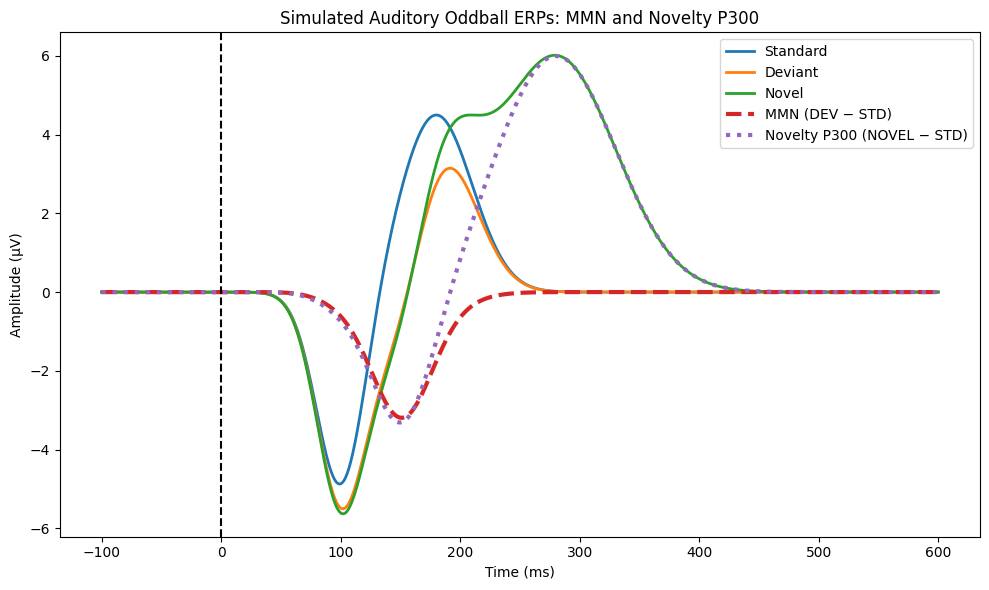

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Time axis
sfreq = 1000
t = np.linspace(-0.1, 0.6, int(0.7 * sfreq))

def gaussian(t, peak, amp, width):
    return amp * np.exp(-0.5 * ((t - peak) / width) ** 2)

# ---- Standard ----
STD = (
    gaussian(t, 0.10, -5.0, 0.02) +   # N1
    gaussian(t, 0.18, 4.5, 0.03)      # P2
)

# ---- Deviant ----
DEV = (
    gaussian(t, 0.10, -5.2, 0.02) +   # N1
    gaussian(t, 0.15, -3.0, 0.025) +  # MMN
    gaussian(t, 0.18, 4.2, 0.03)      # P2
)

# ---- Novel ----
NOVEL = (
    gaussian(t, 0.10, -5.3, 0.02) +   # N1
    gaussian(t, 0.15, -3.2, 0.025) +  # MMN
    gaussian(t, 0.18, 4.0, 0.03) +    # P2
    gaussian(t, 0.28, 6.0, 0.05)      # Novelty P300 (P3a)
)

# ---- Difference waves ----
MMN = DEV - STD
P3a = NOVEL - STD

# ---- Plot ----
plt.figure(figsize=(10, 6))
plt.plot(t * 1000, STD, label="Standard", linewidth=2)
plt.plot(t * 1000, DEV, label="Deviant", linewidth=2)
plt.plot(t * 1000, NOVEL, label="Novel", linewidth=2)
plt.plot(t * 1000, MMN, label="MMN (DEV − STD)", linestyle='--', linewidth=3)
plt.plot(t * 1000, P3a, label="Novelty P300 (NOVEL − STD)", linestyle=':', linewidth=3)

plt.axvline(0, color='k', linestyle='--')
plt.gca()
plt.xlabel("Time (ms)")
plt.ylabel("Amplitude (µV)")
plt.title("Simulated Auditory Oddball ERPs: MMN and Novelty P300")
plt.legend()
plt.tight_layout()
plt.show()


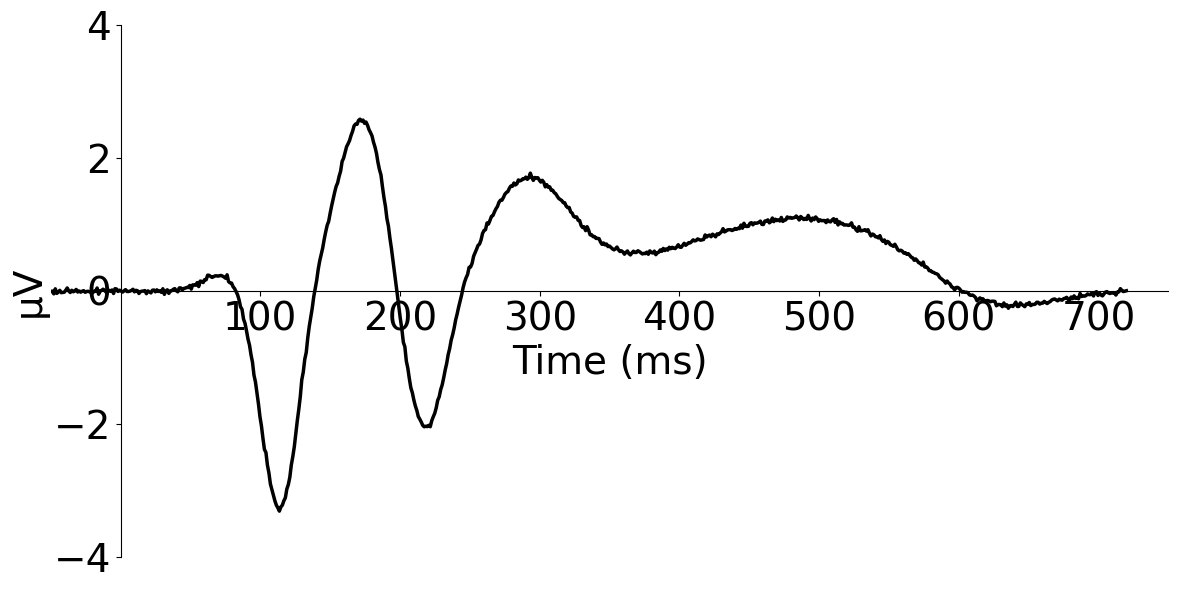

In [56]:
import numpy as np
import matplotlib.pyplot as plt

# Time axis (ms)
time = np.linspace(-50, 720, 721)
plt.rcParams.update({
        'xtick.labelsize':28,
        'ytick.labelsize':28,
        'axes.labelsize':28,
        'axes.titlesize':28,
        'legend.fontsize':28,
    })
# Helper function for ERP components (Gaussian bumps)
def component(t, center, width, amplitude, skew=0.0):
    """
    skew > 0  → right-skewed (long right tail)
    skew < 0  → left-skewed  (long left tail)
    skew = 0  → symmetric
    """
    x = (t - center) / width

    # Gaussian core (sharp)
    gauss = np.exp(-0.5 * x**2)

    # Smooth skew (sigmoid)
    skew_term = 1 / (1 + np.exp(-skew * x))

    return amplitude * gauss * skew_term



erp = (
    component(time, 80, 15, .5, skew=-1.0) + 
    component(time, 120, 15, -6, skew=-1.0) +  # N1 (left-skewed)
    component(time, 190, 25, 6, skew= -1.5) +  # P2 (right-skewed)
    component(time, 230, 35, -3.5, skew=-4.0) +  # MMN
    component(time, 270, 40,  2.5, skew= 2.0) +  # P3a
    component(time, 450, 100,  2.0, skew= 1.0) +   # LPP
    component(time, 600, 50,  -1.0, skew= 1.0) 
)


# Small noise for realism
np.random.seed(2)
erp += 0.02 * np.random.randn(len(time))

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
plt.plot(time, erp, color="black", linewidth=2.5)

# # Zero line
# plt.axhline(0, color="gray", linewidth=1)


ax = plt.gca()

# Move axes to (0, 0)
ax.spines["left"].set_position(("data", 0))
ax.spines["bottom"].set_position(("data", 0))

# Remove unused spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Ticks only on remaining axes
ax.xaxis.set_ticks_position("bottom")
ax.yaxis.set_ticks_position("left")
ax.patch.set_alpha(0)
fig.patch.set_alpha(0)

plt.ylim(-4, 4)
plt.xlabel("Time (ms)", fontsize=28,)
plt.ylabel("µV", fontsize=28)
# remove y-axis zero tick to avoid double "0"
xticks = ax.get_xticks()
ax.set_xticks([100,200,300,400,500,600,700])
plt.xlim(-50,750)

plt.tight_layout()
plt.show()


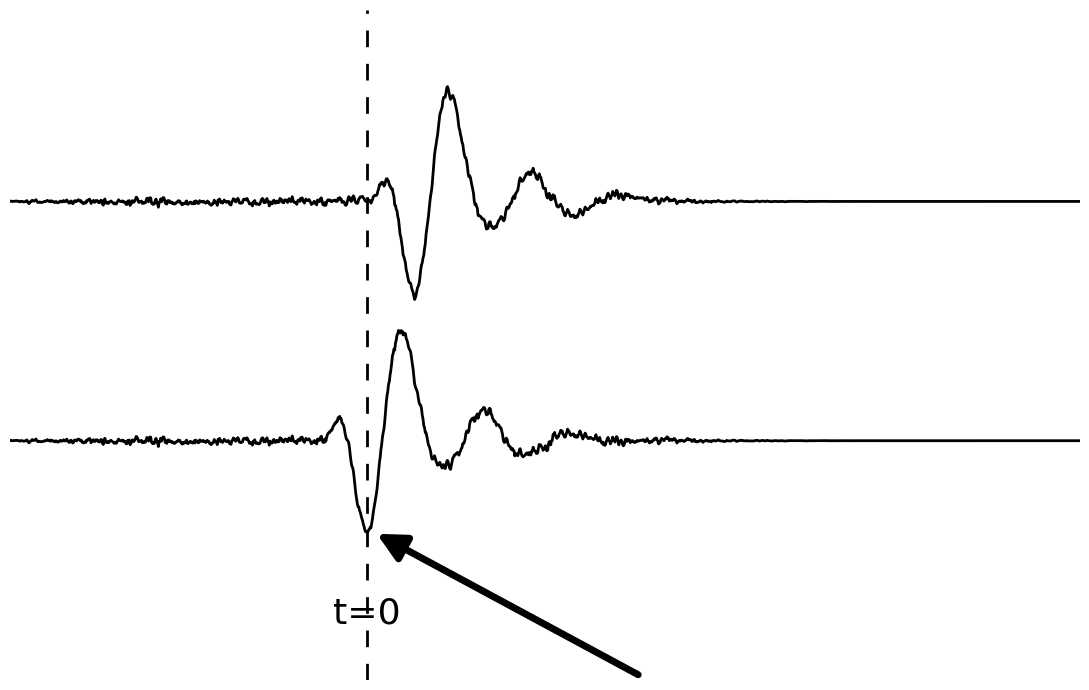

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch

def deflection(t, t0=0.0):
    """Small UP blip -> big DOWN spike -> big UP spike -> ring, anchored so the
    initial up-blip sits at t0 (i.e. at the t=0 line)."""
    x = t - t0
    g = lambda c, w, a: a * np.exp(-0.5 * ((x - c) / w) ** 2)
    core = g(0, 7, 1.3) + g(22, 11, -4.4) + g(48, 13, 5.0) + g(82, 16, -1.3)  # up, down, up, dip
    ring = g(118, 14, 1.4) + g(152, 16, -0.7) + g(188, 18, 0.4)
    env = 1 / (1 + np.exp((x - 235) / 25))
    return core + ring * env

def trace(t, scale=1.0, seed=0, shift=0.0):
    rng = np.random.default_rng(seed)
    noise = rng.standard_normal(t.size)
    noise = np.convolve(noise, np.ones(3) / 3, mode="same") * 0.18
    env = 1 / (1 + np.exp((np.abs(t) - 260) / 30))
    return scale * deflection(t, t0=shift) + noise * env

t = np.linspace(-300, 600, 1400)
top = trace(t, scale=1.00, seed=1,shift = 20)            # up-blip at t=0
bot = trace(t, scale=1.00, seed=1,shift = -20) - 10.0      # same alignment, smaller, lower

fig, ax = plt.subplots(figsize=(11, 7))
ax.plot(t, top, color="black", lw=2.0, solid_capstyle="round")
ax.plot(t, bot, color="black", lw=2.0, solid_capstyle="round")

ax.axvline(0, color="black", lw=2.0, ls=(0, (6, 6)))     # now lands on the up-blip
ax.text(0, -16.5, "t=0", ha="center", va="top", fontsize=26)

# arrow -> lower trace's down-spike trough
mask = (t > 0) & (t < 60)
i = np.where(mask)[0][np.argmin(bot[mask])]
ax.add_patch(FancyArrowPatch((t[i] + 230, bot[i] - 6), (t[i] + 6, bot[i]),
                             arrowstyle="-|>", mutation_scale=42, lw=5, color="black"))

ax.set_xlim(-300, 600)
ax.set_ylim(-20, 8)
ax.axis("off")
plt.tight_layout()
plt.savefig("two_waveforms.png", dpi=200, transparent=True)
plt.show()